# 7. Gas giants: fixed-Q vs fixed-dt

For a hot gas giant on a short-period orbit, tidal dissipation both heats the planet and slowly
circularizes the orbit. Two analytic tide models are in common use and differ in how their lag depends
on the tidal frequency:

- **constant phase lag (fixed-Q)**: the lag angle is the same at every frequency,
- **constant time lag (fixed-dt)**: the lag *time* is the same, so the lag angle grows with frequency.

Because a shorter orbit means a higher tidal frequency, the two models predict a different dependence
of heating and circularization on orbital period. This notebook builds a sub-Saturn around a Sun-like
star and compares them across period, for three values of `Q` and three values of the time lag `dt`.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G
from TidalPy.structures_x.system import System
from TidalPy.structures_x.worlds.stellar import StarWorld
from TidalPy.structures_x.configs import build_world
from TidalPy.Tides_x.classes import make_tide

YEAR = 3.15576e7
M_STAR = 1.0e30
E0 = 0.1                 # present-day eccentricity

star = StarWorld("Star", 6.957e8, M_STAR)
star.set_effective_temperature(5772.0)

planet = build_world({
    "schema_version": "0.2.0", "name": "SubSaturn", "type": "gasgiant",
    "radius_m": 5.6e7, "mass_kg": 5.7e26, "spin_frequency_rad_s": 1.0e-4,
    "layers": {"envelope": {"class": "gas", "type": "gas", "layer_index": 0,
                            "radius_fraction": 1.0, "is_tidal": True}},
})

system = System("hot-subsaturn")
system.add_world(star, is_host=True, is_star=True)
system.add_world(planet, semi_major_axis=0.05 * 1.496e11, eccentricity=E0)
print("system:", [w.name for w in system])


system: ['Star', 'SubSaturn']


## Sweeping orbital period

For each orbital period we set the corresponding semi-major axis (Kepler), spin the planet synchronously (spin = mean motion), attach the chosen tide model, and read the tidal heating and the eccentricity rate `de/dt` from the system's one-step evolution. The circularization timescale is the eccentricity divided by that rate.

In [2]:
periods_days = np.logspace(0.0, 1.5, 40)      # 1 to ~32 days

def sweep(model_name, param_key, param_value, fixed_k=0.5):
    heating = np.empty_like(periods_days)
    tau_circ = np.empty_like(periods_days)
    for i, p_days in enumerate(periods_days):
        p = p_days * 86400.0
        a = (G * M_STAR * p**2 / (4.0 * np.pi**2))**(1.0 / 3.0)
        n = 2.0 * np.pi / p
        system.set_semi_major_axis(planet, a)
        system.set_eccentricity(planet, E0)
        planet.set_spin_frequency(n)                      # synchronous rotation
        planet.set_tide_model(make_tide(model_name,
                              {"fixed_k": [fixed_k], param_key: [param_value]}))
        planet.set_tide_config(min_degree_l=2, max_degree_l=2,
                               eccentricity_truncation=2, obliquity_truncation=0)
        ev = system.calc_world_evolution(planet)
        heating[i] = ev["tidal_heating"]
        tau_circ[i] = E0 / abs(ev["de_dt"]) / YEAR
    return heating, tau_circ

q_values = [1.0e4, 1.0e5, 1.0e6]
dt_values = [0.1, 1.0, 10.0]        # seconds
q_curves = {q: sweep("fixed_q", "fixed_q", q) for q in q_values}
dt_curves = {dt: sweep("fixed_dt", "fixed_dt", dt) for dt in dt_values}
print("swept", len(periods_days), "periods for", len(q_values), "Q and", len(dt_values), "dt values")


swept 40 periods for 3 Q and 3 dt values


Tidal heating versus orbital period. Both models rise steeply toward short periods, but the constant-time-lag model steepens faster because its lag angle grows with the (higher) tidal frequency of a tight orbit.

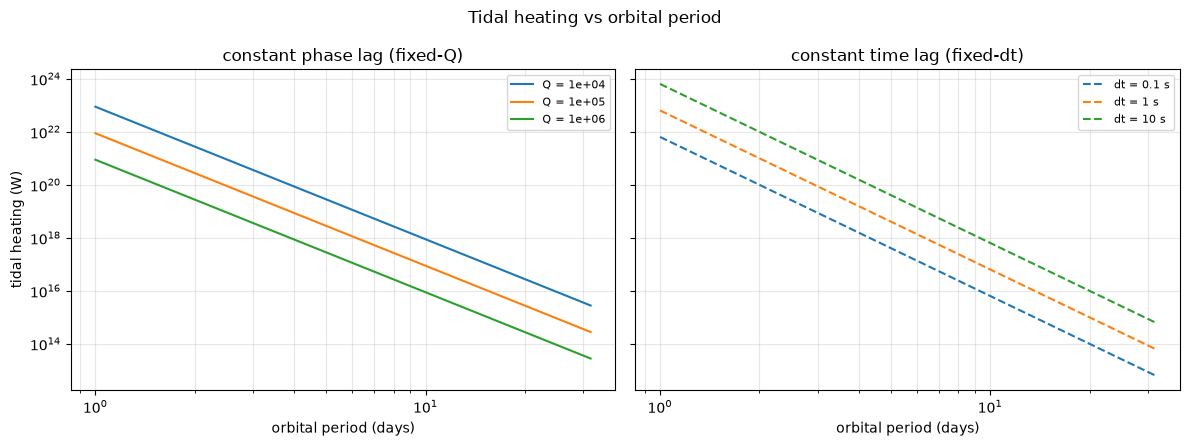

In [3]:
fig, (ax_q, ax_dt) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for q in q_values:
    ax_q.loglog(periods_days, q_curves[q][0], label=f"Q = {q:.0e}")
for dt in dt_values:
    ax_dt.loglog(periods_days, dt_curves[dt][0], "--", label=f"dt = {dt:g} s")
ax_q.set_title("constant phase lag (fixed-Q)")
ax_dt.set_title("constant time lag (fixed-dt)")
for ax in (ax_q, ax_dt):
    ax.set_xlabel("orbital period (days)")
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=8)
ax_q.set_ylabel("tidal heating (W)")
fig.suptitle("Tidal heating vs orbital period")
fig.tight_layout()
plt.show()


Circularization timescale versus orbital period. Short-period planets circularize fastest; the shaded line marks the age of a typical system (about 5 Gyr), below which the orbit would have circularized by now.

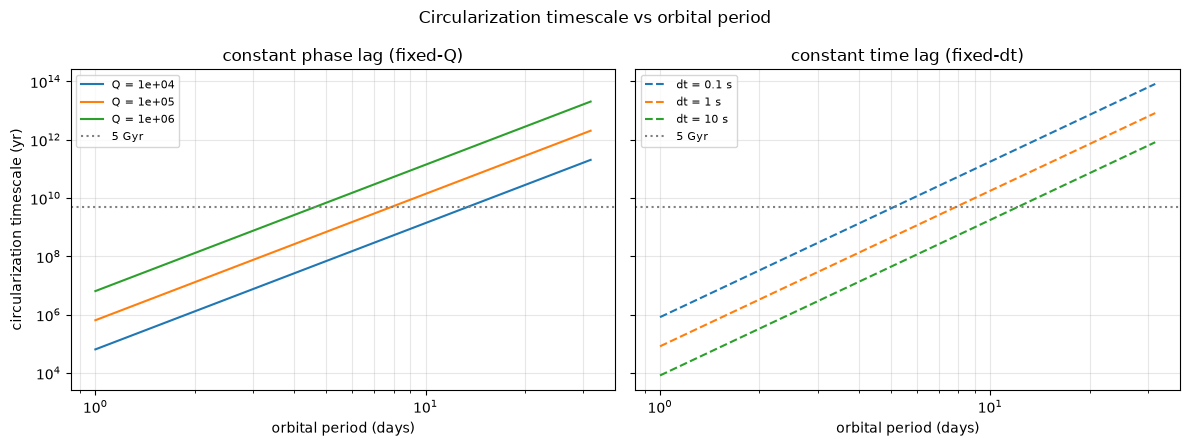

In [4]:
fig, (ax_q, ax_dt) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for q in q_values:
    ax_q.loglog(periods_days, q_curves[q][1], label=f"Q = {q:.0e}")
for dt in dt_values:
    ax_dt.loglog(periods_days, dt_curves[dt][1], "--", label=f"dt = {dt:g} s")
for ax in (ax_q, ax_dt):
    ax.axhline(5.0e9, color="gray", ls=":", label="5 Gyr")
    ax.set_xlabel("orbital period (days)")
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=8)
ax_q.set_title("constant phase lag (fixed-Q)")
ax_dt.set_title("constant time lag (fixed-dt)")
ax_q.set_ylabel("circularization timescale (yr)")
fig.suptitle("Circularization timescale vs orbital period")
fig.tight_layout()
plt.show()


## Recap

- The system's `calc_world_evolution` returns, in one call, the tidal heating and the orbital rates
  (`da_dt`, `de_dt`, `dn_dt`) for the attached tide model; the circularization timescale is
  `e / |de_dt|`.
- Fixed-Q and fixed-dt agree in spirit but differ in frequency dependence, so they diverge toward short
  periods. Which one to trust depends on the physics you believe sets the lag.
- The same planet is swept across many orbits just by updating its orbital elements and tide model, no
  rebuild required.

Next: **`08_love_numbers_1d`** computes Love numbers for layered interiors with the radial solver.
